In [91]:
import os
os.getcwd()
os.listdir('/Users/sreeya/Documents/Healthcare Analytics/Data')

['KaggleV2-May-2016.csv']

In [18]:
import pandas as pd

df = pd.read_csv("/Users/sreeya/Documents/Healthcare Analytics/Data/KaggleV2-May-2016.csv")

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [21]:
df.shape


(110527, 14)

In [22]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [23]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [24]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [25]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.rename(columns={
    'PatientId':'patient_id',
    'AppointmentID':'appointment_id',
    'Gender':'gender',
    'ScheduledDay':'scheduled_date',
    'AppointmentDay':'appointment_date',
    'Age':'age',
    'Neighbourhood':'neighbourhood',
    'Scholarship':'scholarship',
    'Hipertension':'hypertension',
    'Diabetes':'diabetes',
    'Alcoholism':'alcoholism',
    'Handcap':'handicap',
    'SMS_received':'sms_received',
    'No-show':'no_show'
}, inplace=True)

In [28]:
df.columns

Index(['patient_id', 'appointment_id', 'gender', 'scheduled_date',
       'appointment_date', 'age', 'neighbourhood', 'scholarship',
       'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received',
       'no_show'],
      dtype='object')

In [29]:
df['scheduled_date'] = pd.to_datetime(df['scheduled_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

In [36]:
df['age'].min(), df['age'].max()

(0, 115)

In [35]:
df[df['age'] < 0]

,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show


In [32]:
df[df['age'] > 100]

,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show
58014,9.762948e+14,5651757,F,2016-05-03 09:14:53+00:00,2016-05-03 00:00:00+00:00,102,CONQUISTA,0,0,0,0,0,0,No
63912,3.196321e+13,5700278,F,2016-05-16 09:17:44+00:00,2016-05-19 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,Yes
63915,3.196321e+13,5700279,F,2016-05-16 09:17:44+00:00,2016-05-19 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,Yes
68127,3.196321e+13,5562812,F,2016-04-08 14:29:17+00:00,2016-05-16 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,Yes
76284,3.196321e+13,5744037,F,2016-05-30 09:44:51+00:00,2016-05-30 00:00:00+00:00,115,ANDORINHAS,0,0,0,0,1,0,No
90372,2.342836e+11,5751563,F,2016-05-31 10:19:49+00:00,2016-06-02 00:00:00+00:00,102,MARIA ORTIZ,0,0,0,0,0,0,No
97666,7.482346e+14,5717451,F,2016-05-19 07:57:56+00:00,2016-06-03 00:00:00+00:00,115,SÃO JOSÉ,0,1,0,0,0,1,No


In [34]:
median_age = df[df['age'] >= 0]['age'].median()

df.loc[df['age'] < 0, 'age'] = median_age

In [37]:
df.head()


,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [38]:
df.to_csv("healthcare_cleaned.csv", index=False)

In [39]:
df.columns

Index(['patient_id', 'appointment_id', 'gender', 'scheduled_date',
       'appointment_date', 'age', 'neighbourhood', 'scholarship',
       'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received',
       'no_show'],
      dtype='object')

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   patient_id        110527 non-null  float64            
 1   appointment_id    110527 non-null  int64              
 2   gender            110527 non-null  object             
 3   scheduled_date    110527 non-null  datetime64[ns, UTC]
 4   appointment_date  110527 non-null  datetime64[ns, UTC]
 5   age               110527 non-null  int64              
 6   neighbourhood     110527 non-null  object             
 7   scholarship       110527 non-null  int64              
 8   hypertension      110527 non-null  int64              
 9   diabetes          110527 non-null  int64              
 10  alcoholism        110527 non-null  int64              
 11  handicap          110527 non-null  int64              
 12  sms_received      110527 non-null  int64    

In [43]:
df.head()

,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [44]:
df.describe()

,patient_id,appointment_id,age,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.089218,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.109921,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


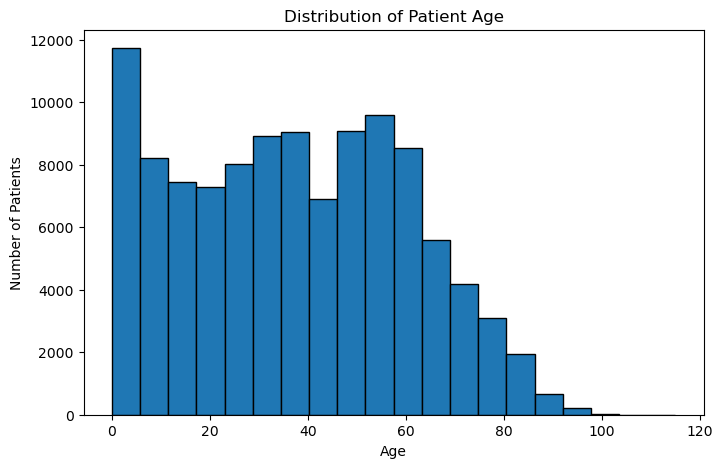

In [49]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20, edgecolor="black", linewidth=1)
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

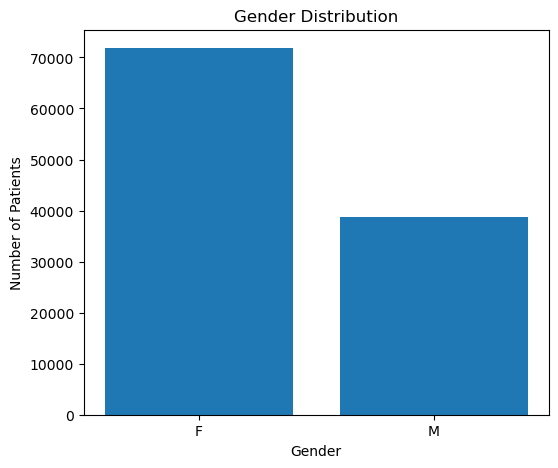

In [52]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

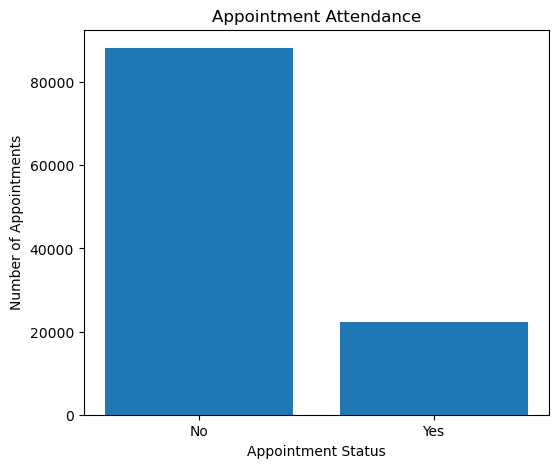

In [53]:
no_show_counts = df["no_show"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(no_show_counts.index, no_show_counts.values)
plt.title("Appointment Attendance")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")
plt.show()

In [54]:
"waiting_days" in df.columns

False

In [55]:
df["scheduled_date"] = pd.to_datetime(df["scheduled_date"])
df["appointment_date"] = pd.to_datetime(df["appointment_date"])

In [56]:
df["waiting_days"] = (
    df["appointment_date"] - df["scheduled_date"]
).dt.days

In [57]:
df[["scheduled_date", "appointment_date", "waiting_days"]].head()

,scheduled_date,appointment_date,waiting_days
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,-1
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,-1
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,-1
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,-1
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,-1


In [62]:
df[df["waiting_days"] < 0]

,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,waiting_days
27033,7.839273e+12,5679978,M,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,Yes,-1
55226,7.896294e+12,5715660,F,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,Yes,-1
64175,2.425226e+13,5664962,F,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,Yes,-1
71533,9.982316e+14,5686628,F,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,Yes,-6
72362,3.787482e+12,5655637,M,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,Yes,-1


In [59]:
df["waiting_days"] = (
    df["appointment_date"].dt.normalize()
    - df["scheduled_date"].dt.normalize()
).dt.days

In [63]:
df_valid=df[df["waiting_days"]>=0].copy()

In [66]:
df_valid[df_valid["waiting_days"]<0]

,patient_id,appointment_id,gender,scheduled_date,appointment_date,age,neighbourhood,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,no_show,waiting_days


In [67]:

df["age_group"] = pd.cut(
    df["age"],
    bins=[-1, 17, 35, 60, 120],
    labels=["Child", "Young Adult", "Adult", "Senior"]
)

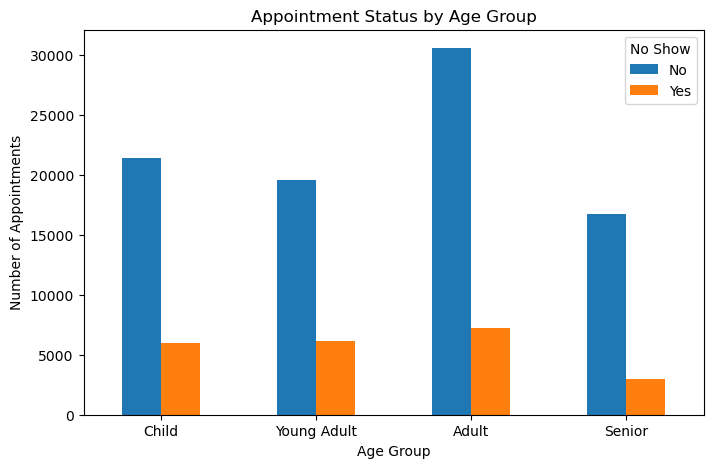

In [68]:
age_noshow = pd.crosstab(df["age_group"], df["no_show"])

age_noshow.plot(kind="bar", figsize=(8,5))

plt.title("Appointment Status by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.legend(title="No Show")
plt.show()

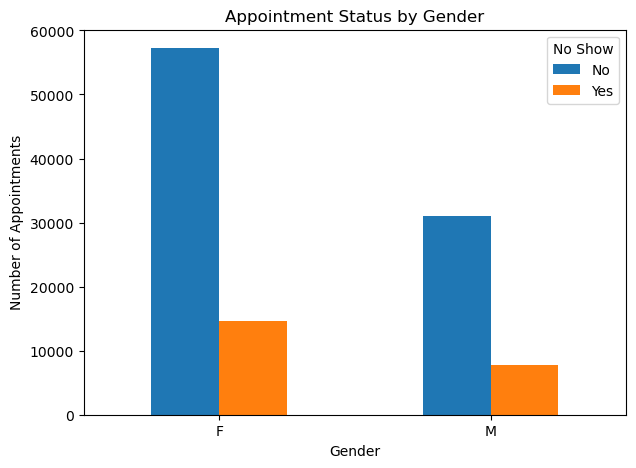

In [69]:
gender_noshow = pd.crosstab(df["gender"], df["no_show"])

gender_noshow.plot(kind="bar", figsize=(7,5))

plt.title("Appointment Status by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.legend(title="No Show")
plt.show()

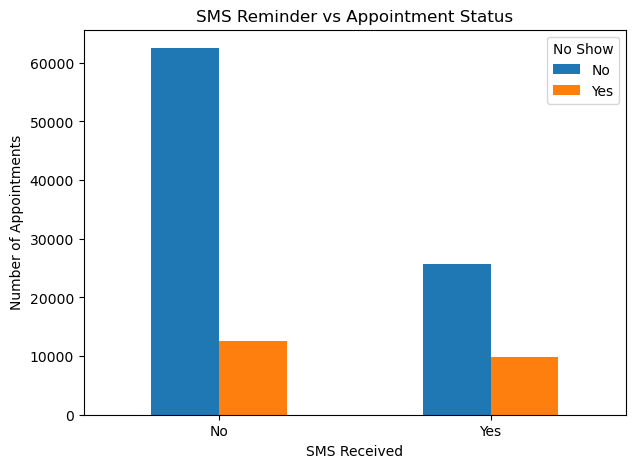

In [70]:
sms_noshow = pd.crosstab(df["sms_received"], df["no_show"])

sms_noshow.plot(kind="bar", figsize=(7,5))

plt.title("SMS Reminder vs Appointment Status")
plt.xlabel("SMS Received")
plt.ylabel("Number of Appointments")
plt.xticks([0,1], ["No", "Yes"], rotation=0)
plt.legend(title="No Show")
plt.show()

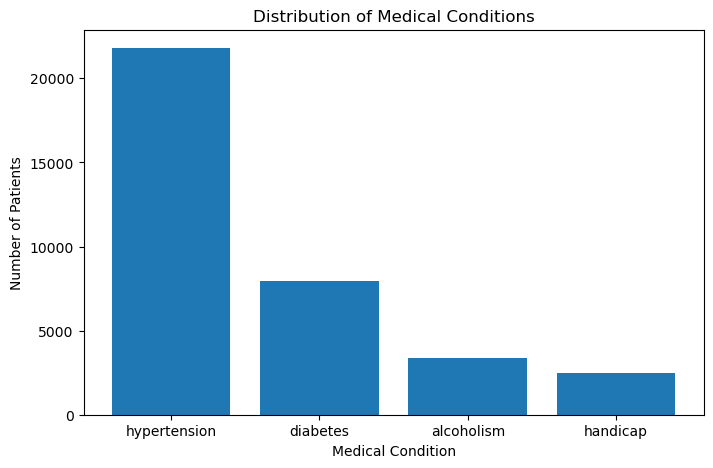

In [71]:
conditions = [
    "hypertension",
    "diabetes",
    "alcoholism",
    "handicap"
]

condition_counts = df[conditions].sum()

plt.figure(figsize=(8,5))
plt.bar(condition_counts.index, condition_counts.values)

plt.title("Distribution of Medical Conditions")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")
plt.show()

In [72]:
df["no_show_numeric"] = df["no_show"].map({"No": 0, "Yes": 1})

In [73]:
df[["no_show", "no_show_numeric"]].head()

,no_show,no_show_numeric
0,No,0
1,No,0
2,No,0
3,No,0
4,No,0


In [74]:
numeric_df = df[[
    "age",
    "scholarship",
    "hypertension",
    "diabetes",
    "alcoholism",
    "handicap",
    "sms_received",
    "waiting_days",
    "no_show_numeric"
]]

In [75]:
correlation = numeric_df.corr()
correlation

,age,scholarship,hypertension,diabetes,alcoholism,handicap,sms_received,waiting_days,no_show_numeric
age,1.000000,-0.092463,0.504585,0.292391,0.095810,0.078032,0.012633,0.034811,-0.060327
scholarship,-0.092463,1.000000,-0.019729,-0.024894,0.035022,-0.008586,0.001194,-0.030421,0.029135
hypertension,0.504585,-0.019729,1.000000,0.433086,0.087971,0.080083,-0.006267,-0.017215,-0.035701
diabetes,0.292391,-0.024894,0.433086,1.000000,0.018474,0.057530,-0.014550,-0.027188,-0.015180
alcoholism,0.095810,0.035022,0.087971,0.018474,1.000000,0.004648,-0.026147,-0.038519,-0.000196
handicap,0.078032,-0.008586,0.080083,0.057530,0.004648,1.000000,-0.024161,-0.019843,-0.006076
sms_received,0.012633,0.001194,-0.006267,-0.014550,-0.026147,-0.024161,1.000000,0.398145,0.126431
waiting_days,0.034811,-0.030421,-0.017215,-0.027188,-0.038519,-0.019843,0.398145,1.000000,0.186231
no_show_numeric,-0.060327,0.029135,-0.035701,-0.015180,-0.000196,-0.006076,0.126431,0.186231,1.000000


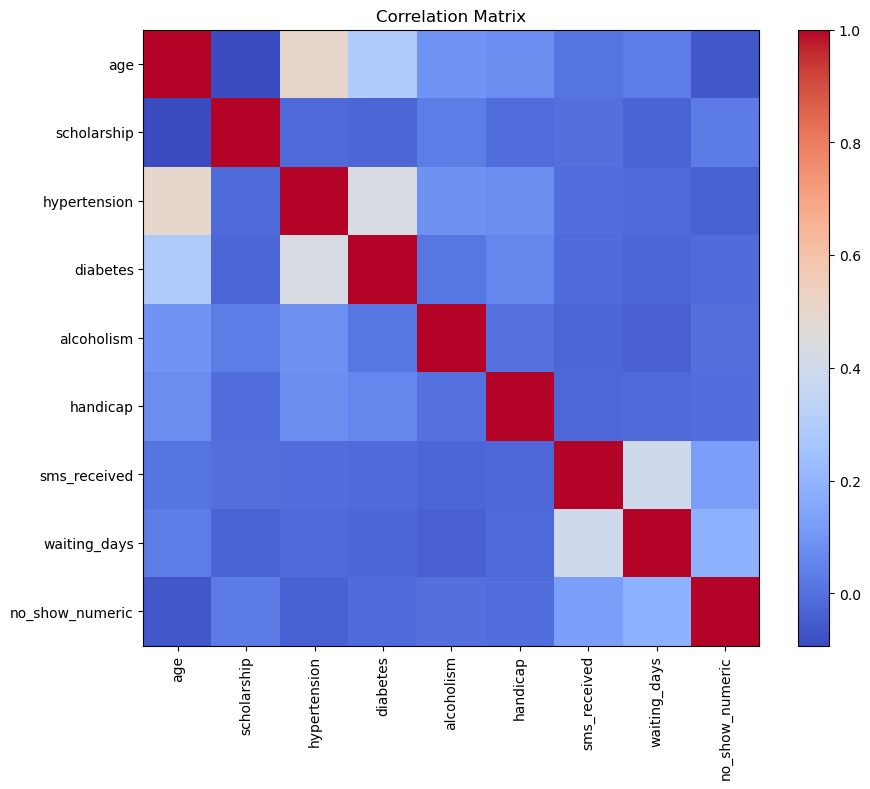

In [76]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

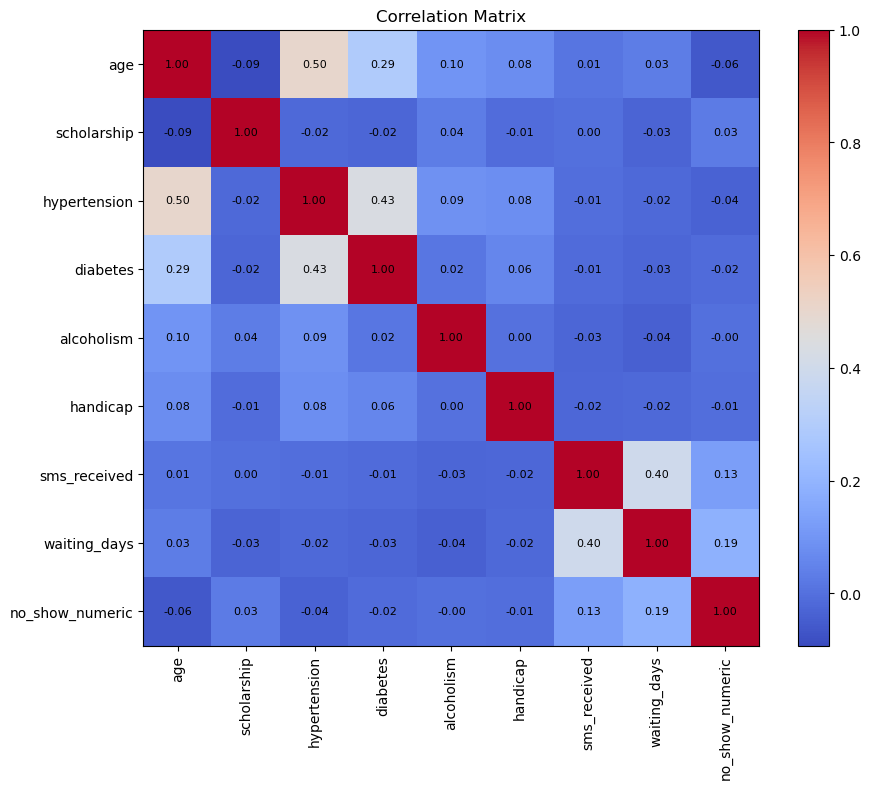

In [77]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i,
                 f"{correlation.iloc[i, j]:.2f}",
                 ha="center",
                 va="center",
                 fontsize=8)

plt.title("Correlation Matrix")
plt.show()

In [78]:
from scipy import stats

In [79]:
attended = df_valid[df_valid["no_show"] == "No"]["waiting_days"]
missed = df_valid[df_valid["no_show"] == "Yes"]["waiting_days"]

In [80]:
t_stat, p_value = stats.ttest_ind(attended, missed)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -63.04594591751336
P-value: 0.0


Conclusion

There is a statistically significant difference in waiting days between patients who attended their appointments and those who missed them.

This suggests that waiting time is associated with appointment attendance.

The negative t-statistic indicates that the average waiting time for the attended group is lower than that for the missed (no_show) group. In other words, patients who waited longer were more likely to miss their appointments.

In [81]:
contingency_table = pd.crosstab(df["sms_received"], df["no_show"])

contingency_table

no_show,No,Yes
sms_received,,
0,62510,12535
1,25698,9784


In [82]:
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square Statistic:", chi2)
print("P-value:", p_value)

Chi-square Statistic: 1766.0676572637585
P-value: 0.0


Chi-Square test tells us there is an association, but it does not tell us whether SMS reminders improved attendance or made it worse. To answer that, we need to look at the actual attendance rates in each group.

In [83]:
pd.crosstab(
    df["sms_received"],
    df["no_show"],
    normalize="index"
) * 100

no_show,No,Yes
sms_received,,
0,83.296689,16.703311
1,72.425455,27.574545


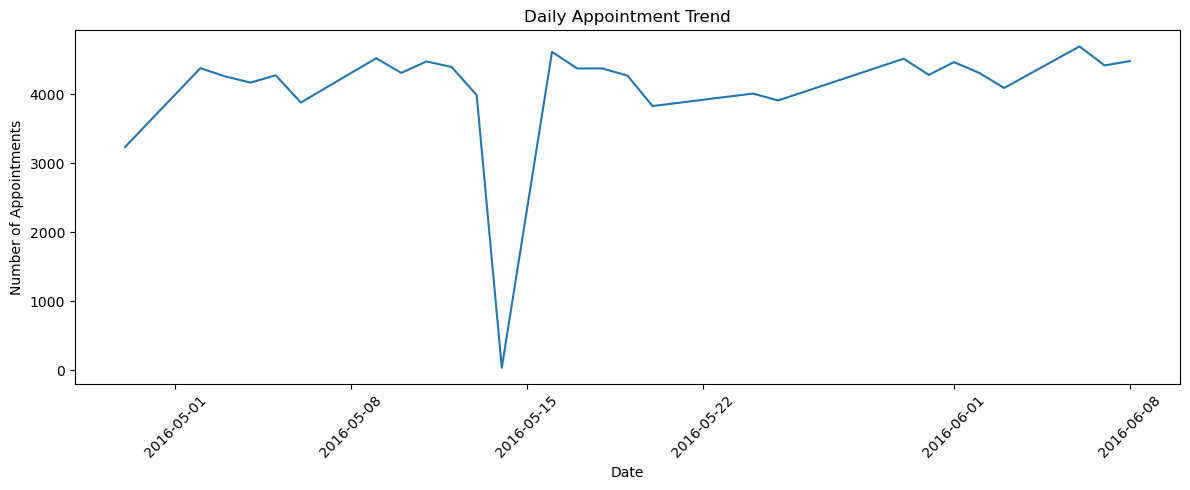

In [84]:
appointments_by_day = (
    df.groupby(df["appointment_date"].dt.date)
      .size()
)

plt.figure(figsize=(12,5))
plt.plot(appointments_by_day.index, appointments_by_day.values)

plt.title("Daily Appointment Trend")
plt.xlabel("Date")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

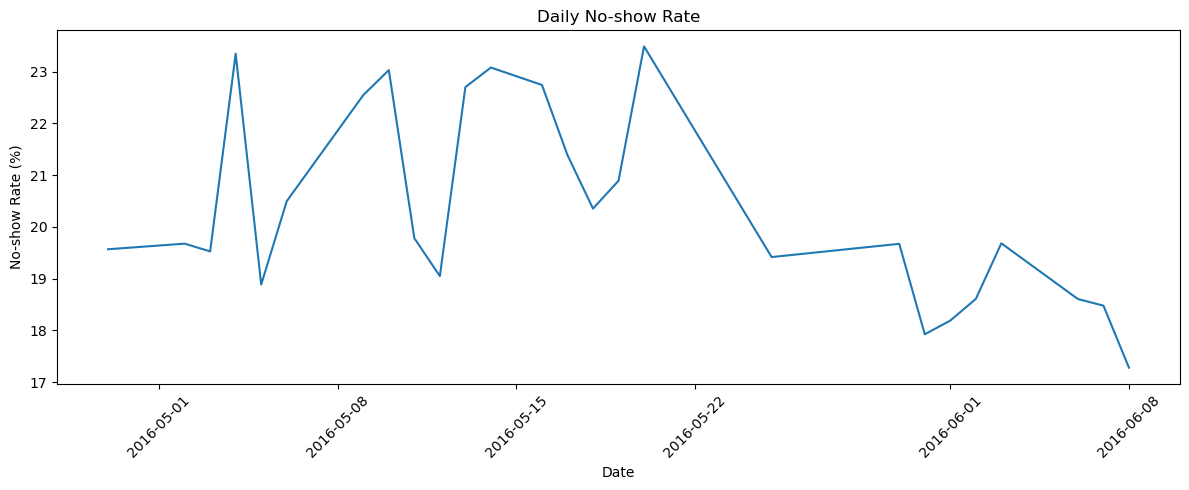

In [85]:
daily_noshow = (
    df.groupby(df["appointment_date"].dt.date)["no_show_numeric"]
      .mean()
      * 100
)

plt.figure(figsize=(12,5))
plt.plot(daily_noshow.index, daily_noshow.values)

plt.title("Daily No-show Rate")
plt.xlabel("Date")
plt.ylabel("No-show Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

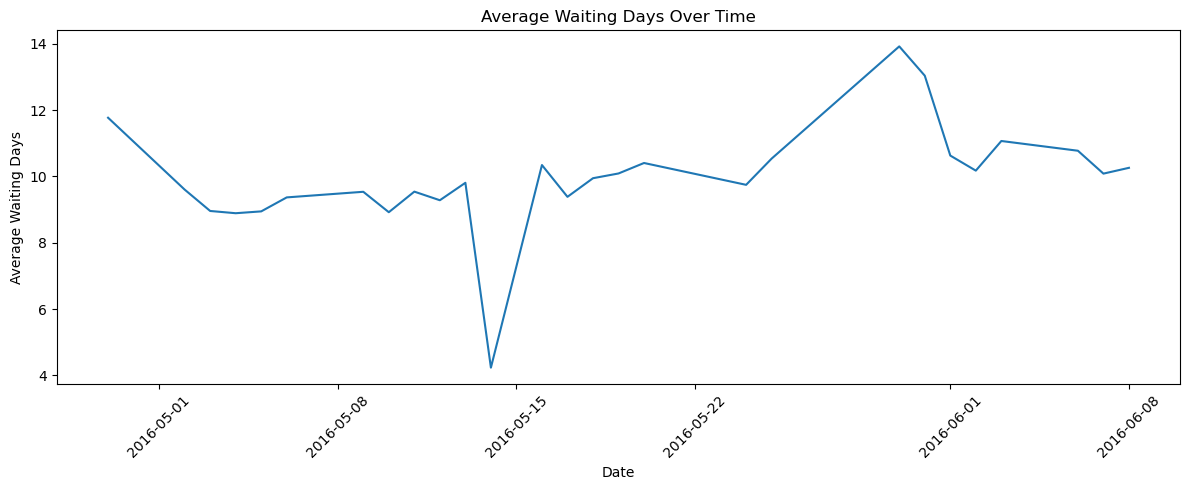

In [86]:
waiting_trend = (
    df_valid.groupby(df_valid["appointment_date"].dt.date)["waiting_days"]
            .mean()
)

plt.figure(figsize=(12,5))
plt.plot(waiting_trend.index, waiting_trend.values)

plt.title("Average Waiting Days Over Time")
plt.xlabel("Date")
plt.ylabel("Average Waiting Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [87]:
df["appointment_status"] = df["no_show"].map({
    "No": "Attended",
    "Yes": "Missed"
})

In [88]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[-1,17,35,60,120],
    labels=["Child","Young Adult","Adult","Senior"]
)

In [89]:
df_valid["waiting_category"] = pd.cut(
    df_valid["waiting_days"],
    bins=[-1,0,7,30,1000],
    labels=[
        "Same Day",
        "1-7 Days",
        "8-30 Days",
        "30+ Days"
    ]
)

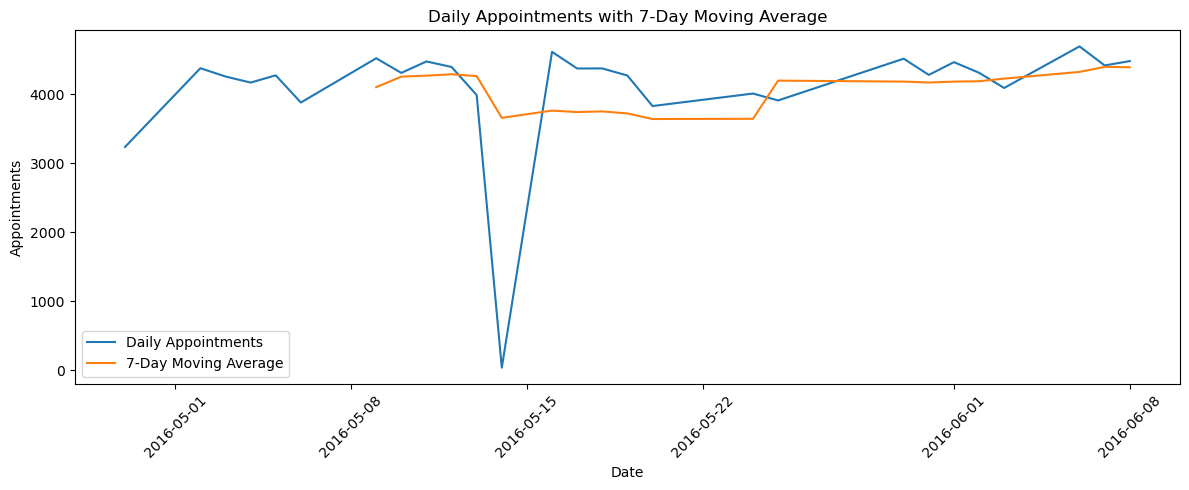

In [90]:
appointments_by_day = appointments_by_day.to_frame(name="appointments")

appointments_by_day["moving_average"] = (
    appointments_by_day["appointments"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12,5))
plt.plot(
    appointments_by_day.index,
    appointments_by_day["appointments"],
    label="Daily Appointments"
)

plt.plot(
    appointments_by_day.index,
    appointments_by_day["moving_average"],
    label="7-Day Moving Average"
)

plt.title("Daily Appointments with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Appointments")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Key Insights

1. Appointment attendance is strongly influenced by waiting time. Patients with longer waiting periods were significantly more likely to miss their appointments (supported by the t-test).
2. SMS reminders are significantly associated with appointment attendance. The Chi-Square test showed a statistically significant relationship between SMS reminders and attendance. Further analysis of attendance rates is needed to understand the direction of this association.
3. No single factor strongly predicts no-shows. Correlation analysis indicated that missed appointments are influenced by multiple factors rather than one dominant variable.
4. Older patients are more likely to have hypertension and diabetes. The correlation analysis showed expected positive relationships between age and chronic medical conditions.
5. Patient demand varies over time. Trend analysis revealed fluctuations in appointment volumes, helping identify periods that may require different staffing levels.
6. A small number of data-quality issues were identified. Five records had negative waiting times and were excluded from waiting-time analyses to ensure reliable results.

Recommendations

* Reduce waiting times to help lower appointment no-show rates.
* Continue evaluating and optimizing SMS reminder strategies.
* Allocate hospital resources based on observed appointment trends.
* Prioritize preventive care and chronic disease management for older patients.
* Implement regular data validation to improve the quality of operational reporting.